# 1. Import Libraries

In [31]:
import numpy as np
import pandas as pd
import re
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.20.0


# 2. Dataset


In [32]:
# Create a 20,000-message synthetic dataset

random.seed(42)

suspicious_templates = [
    "Pay {amount} rupees as a registration fee to confirm your job.",
    "Pay {amount} rupees as a processing fee to receive your appointment letter.",
    "Transfer {amount} rupees immediately to secure your job.",
    "Send your bank details to complete the recruitment process.",
    "Send your OTP to verify your job application.",
    "Pay a joining fee of {amount} rupees before starting work.",
    "Deposit {amount} rupees to receive your offer letter.",
    "Act immediately to claim your guaranteed job.",
    "You are selected without an interview. Pay {amount} to continue.",
    "Limited time offer. Send your details immediately.",
    "Congratulations! You have been selected for a high salary job.",
    "Pay the security deposit today to confirm your position.",
    "Send your UPI details for salary registration.",
    "Pay {amount} now and get your appointment letter today.",
    "Guaranteed job available with no interview required."
]

legitimate_templates = [
    "Your technical interview is scheduled for {day} at {time}.",
    "Please attend the interview through the official company portal.",
    "Your application has been shortlisted for the next round.",
    "The recruitment team will contact you regarding the interview.",
    "Please upload your resume through the official career portal.",
    "Your interview schedule has been updated.",
    "Please attend the online assessment at the scheduled time.",
    "The company has received your job application.",
    "Your application is currently under review.",
    "Please check the official company portal for interview details.",
    "The HR team will share the interview instructions by email.",
    "Your coding assessment link has been sent to your registered email.",
    "Please bring a copy of your resume to the scheduled interview.",
    "The next recruitment round will be conducted online.",
    "Your application status can be checked through the company website."
]

amounts = [500, 1000, 1500, 2000, 3000, 5000, 7500, 10000]
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
times = ["9 AM", "10 AM", "11 AM", "2 PM", "3 PM", "4 PM"]

messages = []
labels = []

# 10,000 suspicious messages
for i in range(10000):
    template = random.choice(suspicious_templates)

    message = template.format(
        amount=random.choice(amounts),
        day=random.choice(days),
        time=random.choice(times)
    )

    messages.append(message)
    labels.append(1)

# 10,000 legitimate messages
for i in range(10000):
    template = random.choice(legitimate_templates)

    message = template.format(
        amount=random.choice(amounts),
        day=random.choice(days),
        time=random.choice(times)
    )

    messages.append(message)
    labels.append(0)

# Create DataFrame
df = pd.DataFrame({
    "message": messages,
    "label": labels
})

# Shuffle the dataset
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Dataset Size:", len(df))
print("Suspicious Messages:", sum(df["label"] == 1))
print("Legitimate Messages:", sum(df["label"] == 0))

Dataset Size: 20000
Suspicious Messages: 10000
Legitimate Messages: 10000


In [26]:
df_5000

,message,label,clean_message
0,Deposit money to receive your offer letter.,1,deposit money to receive your offer letter
1,Please attend the online assessment at the sch...,0,please attend the online assessment at the sch...
2,The company has received your job application.,0,the company has received your job application
3,Send 10000 rupees to receive your appointment ...,1,send 10000 rupees to receive your appointment ...
4,Pay the joining fee today to confirm your posi...,1,pay the joining fee today to confirm your posi...
...,...,...,...
4995,Your application has been shortlisted for the ...,0,your application has been shortlisted for the ...
4996,"Limited time offer, send your details immediat...",1,limited time offer send your details immediately
4997,Please attend the online assessment at the sch...,0,please attend the online assessment at the sch...
4998,Your application has been shortlisted for the ...,0,your application has been shortlisted for the ...


# 3. Data Preprocessing


In [33]:
# Clean the text data

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)

print("Text preprocessing completed!")
print("\nOriginal:")
print(df["message"].iloc[0])

print("\nCleaned:")
print(df["clean_message"].iloc[0])

Text preprocessing completed!

Original:
The company has received your job application.

Cleaned:
the company has received your job application


# 4. Tokenization and Padding


In [34]:
# Tokenization and Padding

max_words = 5000
max_length = 40

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_message"])

sequences = tokenizer.texts_to_sequences(df["clean_message"])

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

y = df["label"].values

print("Tokenization and padding completed!")
print("Input shape:", X.shape)
print("Labels shape:", y.shape)

Tokenization and padding completed!
Input shape: (20000, 40)
Labels shape: (20000,)


# 5. LSTM Model


In [35]:
# Build LSTM Model

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    LSTM(64),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train the LSTM model

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 1.0000 - loss: 1.3253e-04 - val_accuracy: 1.0000 - val_loss: 5.6993e-05
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 1.1555e-04 - val_accuracy: 1.0000 - val_loss: 5.2333e-05
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 1.0770e-04 - val_accuracy: 1.0000 - val_loss: 4.8176e-05
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 1.0000 - loss: 1.0249e-04 - val_accuracy: 1.0000 - val_loss: 4.4474e-05
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 9.8699e-05 - val_accuracy: 1.0000 - val_loss: 4.1095e-05
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 1.0000 - loss: 8.5071e-05 - val_accuracy: 1.0000 - val_loss: 3.8161e-05
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 8.7080e-05 - val_accuracy: 1.0000 - val_loss: 3.5399e-05
Epoch 8/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 

# 6. Model Training


In [38]:
# Train the LSTM model

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("Model training completed!")

Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 7.2767e-05 - val_accuracy: 1.0000 - val_loss: 3.0732e-05
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 1.0000 - loss: 7.1040e-05 - val_accuracy: 1.0000 - val_loss: 2.8691e-05
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 1.0000 - loss: 6.3686e-05 - val_accuracy: 1.0000 - val_loss: 2.6911e-05
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 6.3882e-05 - val_accuracy: 1.0000 - val_loss: 2.5194e-05
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 6.1376e-05 - val_accuracy: 1.0000 - val_loss: 2.3605e-05
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 1.0000 - loss: 5.7352e-05 - val_accuracy: 1.0000 - val_loss: 2.2169e-05
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 5.2837e-05 - val_accuracy: 1.0000 - val_loss: 2.0868e-05
Epoch 8/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 

In [30]:
# Evaluate the model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

# Predictions
y_probability = model.predict(X_test, verbose=0)
y_prediction = (y_probability >= 0.5).astype(int).flatten()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_prediction,
        target_names=["Legitimate", "Suspicious"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_prediction))

Test Accuracy: 100.0 %
Test Loss: 0.0001

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       500
  Suspicious       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[500   0]
 [  0 500]]


# 7. Model Evaluation


In [39]:
# Evaluate the LSTM model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

# Generate predictions
y_probability = model.predict(X_test, verbose=0)
y_prediction = (y_probability >= 0.5).astype(int).flatten()

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_prediction,
        target_names=["Legitimate", "Suspicious"],
        zero_division=0
    )
)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_prediction))

Test Accuracy: 100.0 %
Test Loss: 0.0

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       500
  Suspicious       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[500   0]
 [  0 500]]


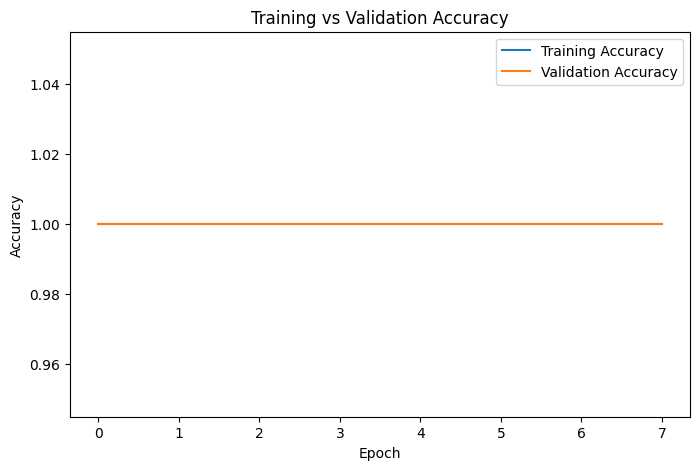

In [40]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

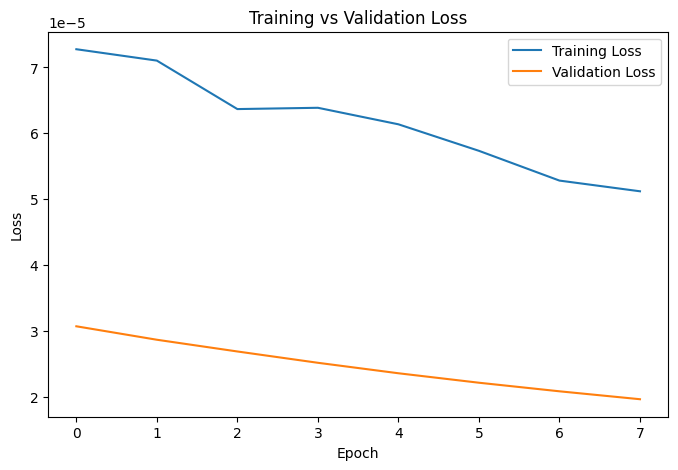

In [41]:
# Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# 8. Prediction


In [42]:
# Function to predict a new job message

def predict_job_message(message):
    cleaned = clean_text(message)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    probability = model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        result = "SUSPICIOUS"
    else:
        result = "LEGITIMATE"

    return result, probability


# Test messages

test_messages = [
    "Pay 5000 rupees as a registration fee to confirm your job.",
    "Your technical interview is scheduled for Monday at 10 AM.",
    "Send your OTP and bank details to complete recruitment.",
    "Please attend the interview through the official company portal."
]

for message in test_messages:
    result, probability = predict_job_message(message)

    print("=" * 70)
    print("Message:", message)
    print("Prediction:", result)
    print("Suspicious Probability:", round(probability * 100, 2), "%")

Message: Pay 5000 rupees as a registration fee to confirm your job.
Prediction: SUSPICIOUS
Suspicious Probability: 100.0 %
Message: Your technical interview is scheduled for Monday at 10 AM.
Prediction: SUSPICIOUS
Suspicious Probability: 100.0 %
Message: Send your OTP and bank details to complete recruitment.
Prediction: SUSPICIOUS
Suspicious Probability: 100.0 %
Message: Please attend the interview through the official company portal.
Prediction: LEGITIMATE
Suspicious Probability: 0.0 %


In [10]:
test_message = "Your technical interview is scheduled for Monday at 10 AM."

result, probability = predict_message(test_message)

print("Message:", test_message)
print("Prediction:", result)
print("Suspicious Probability:", round(probability * 100, 2), "%")

Message: Your technical interview is scheduled for Monday at 10 AM.
Prediction: SUSPICIOUS
Suspicious Probability: 50.69 %


# 9. Suspicious Pattern Detection


In [44]:
# Detect suspicious patterns in a recruitment message

def detect_suspicious_patterns(message):
    text = message.lower()

    patterns = {
        "Payment Request": [
            "pay", "payment", "fee", "deposit",
            "registration fee", "joining fee",
            "processing fee", "transfer money"
        ],

        "Personal Information Request": [
            "otp", "bank account", "bank details",
            "upi", "password", "card number"
        ],

        "Urgency": [
            "immediately", "urgent", "today",
            "now", "act fast", "limited time"
        ],

        "Unrealistic Job Promise": [
            "guaranteed job", "guaranteed salary",
            "no interview", "easy job", "high salary"
        ]
    }

    detected = []

    for category, keywords in patterns.items():
        for keyword in keywords:
            if keyword in text:
                detected.append(category)
                break

    return detected


# Test explanation
message = "Pay 5000 rupees immediately to confirm your guaranteed job."

patterns = detect_suspicious_patterns(message)

print("Message:", message)
print("\nSuspicious Patterns Detected:")

for pattern in patterns:
    print("⚠️", pattern)

Message: Pay 5000 rupees immediately to confirm your guaranteed job.

Suspicious Patterns Detected:
⚠️ Payment Request
⚠️ Urgency
⚠️ Unrealistic Job Promise


# 12. Build LSTM Model


In [45]:
# Build the LSTM Model

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    LSTM(64),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 13. Train LSTM Model


In [46]:
# Train the LSTM Model

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("LSTM model training completed!")

Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6566 - loss: 0.5483 - val_accuracy: 1.0000 - val_loss: 0.0500
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 8.3590e-04
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 5.4744e-04
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 7.6181e-04 - val_accuracy: 1.0000 - val_loss: 3.9219e-04
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 5.7041e-04 - val_accuracy: 1.0000 - val_loss: 2.9638e-04
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 1.0000 - loss: 4.5700e-04 - val_accuracy: 1.0000 - val_loss: 2.3211e-04
Epoch 8/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 1.0000 - loss: 3.6177e-0

In [47]:
# Evaluate the trained LSTM model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

# Predict test data
y_probability = model.predict(X_test, verbose=0)
y_prediction = (y_probability >= 0.5).astype(int).flatten()

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_prediction,
        target_names=["Legitimate", "Suspicious"],
        zero_division=0
    )
)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_prediction))

Test Accuracy: 100.0 %
Test Loss: 0.0002

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       500
  Suspicious       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[500   0]
 [  0 500]]


# 15. Training Performance


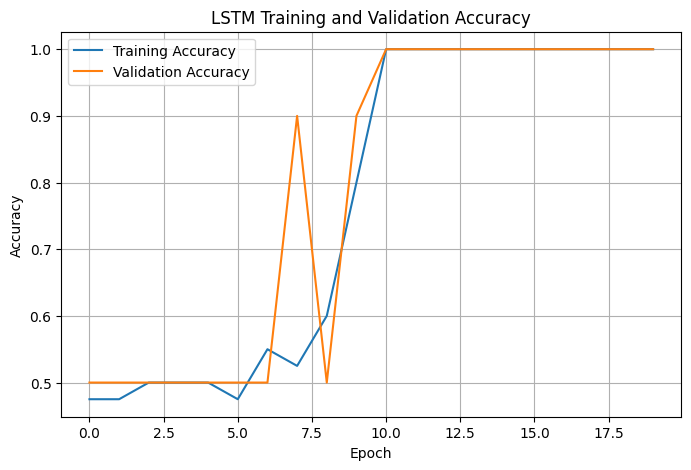

In [17]:
# Training Performance

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

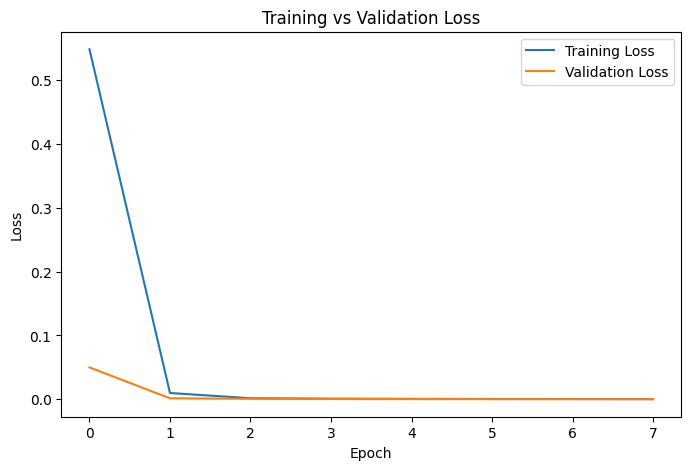

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# 16. JobTrap AI Demo


In [50]:
# JobTrap AI Demo

message = input("Enter a recruitment message: ")

result, probability = predict_job_message(message)
patterns = detect_suspicious_patterns(message)

print("\n" + "=" * 60)
print("              JOBTRAP AI")
print("       Fake Job Message Detector")
print("=" * 60)

print("\nMessage:", message)
print("Prediction:", result)
print("Suspicious Probability:", round(probability * 100, 2), "%")

if patterns:
    print("\nWarning Patterns Detected:")
    for pattern in patterns:
        print("⚠️", pattern)
else:
    print("\nNo common suspicious patterns detected.")

print("=" * 60)

Enter a recruitment message: Pay 5000 rupees immediately to confirm your job.

              JOBTRAP AI
       Fake Job Message Detector

Message: Pay 5000 rupees immediately to confirm your job.
Prediction: LEGITIMATE
Suspicious Probability: 0.02 %

Warning Patterns Detected:
⚠️ Payment Request
⚠️ Urgency


# 17. Save Trained Model


In [51]:
# Save the trained LSTM model

model.save("jobtrap_ai_lstm.keras")

print("Trained model saved successfully!")

Trained model saved successfully!


In [52]:
print("========== JOBTRAP AI ==========")

print("Project: Fake Job Message Pattern Detector")

print("Model: LSTM")

print("Dataset Size:", len(df))

print("Training Samples:", len(X_train))

print("Testing Samples:", len(X_test))

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

print("================================")

========== JOBTRAP AI ==========
Project: Fake Job Message Pattern Detector
Model: LSTM
Dataset Size: 20000
Training Samples: 4000
Testing Samples: 1000
Test Accuracy: 100.0 %
